---
title: "DEL - Mini Challenge"
author: "Luca Manna"
date: "2026-04-17"
format:
  html:
    toc: true
    number-sections: true
    code-fold: show
    embed-resources: true
lang: de
---

# Mini-Challenge DEL: Hyperparameter Tuning und Model Evaluation

**Task:** Bildklassifikation mit dem Intel Image Classification Dataset (6 Klassen: buildings, forest, glacier, mountain, sea, street).

**Stage 1:** Basismodell mit CNN, LR- und Batch-Size-Tuning, Cross-Validation.

## Imports und Setup

Alle benötigten Bibliotheken: PyTorch, torchvision, HuggingFace datasets, scikit-learn, W&B.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset

# HuggingFace datasets
from datasets import load_dataset, load_from_disk

# Scikit-learn (metrics, cross-validation)
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Experiment tracking
import wandb

# Utilities
import os
import time
from pathlib import Path

# GLobal variables
RANDOM_SEED = 42
DATA_DIR = Path("../data/intel-image-classification")

### Daten laden

Intel Image Classification Dataset von HuggingFace laden (bzw. von Disk falls bereits heruntergeladen).

In [2]:
if DATA_DIR.exists():
    print("Loading dataset from disk...")
    dataset = load_from_disk(str(DATA_DIR))
else:
    print("Downloading dataset from HuggingFace...")
    dataset = load_dataset("sfarrukhm/intel-image-classification")
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    dataset.save_to_disk(str(DATA_DIR))
    print(f"Dataset saved to {DATA_DIR}")

print(dataset)
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Test samples:  {len(dataset['test'])}")
print(f"\nFeatures: {dataset['train'].features}")
print(f"Labels:   {dataset['train'].features['label'].names}")

Loading dataset from disk...
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 14034
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})

Train samples: 14034
Test samples:  3000

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])}
Labels:   ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Explorative Analyse

   Klasse  Train  Test  Train %  Test %
buildings   2191   437     15.6    14.6
   forest   2271   474     16.2    15.8
  glacier   2404   553     17.1    18.4
 mountain   2512   525     17.9    17.5
      sea   2274   510     16.2    17.0
   street   2382   501     17.0    16.7


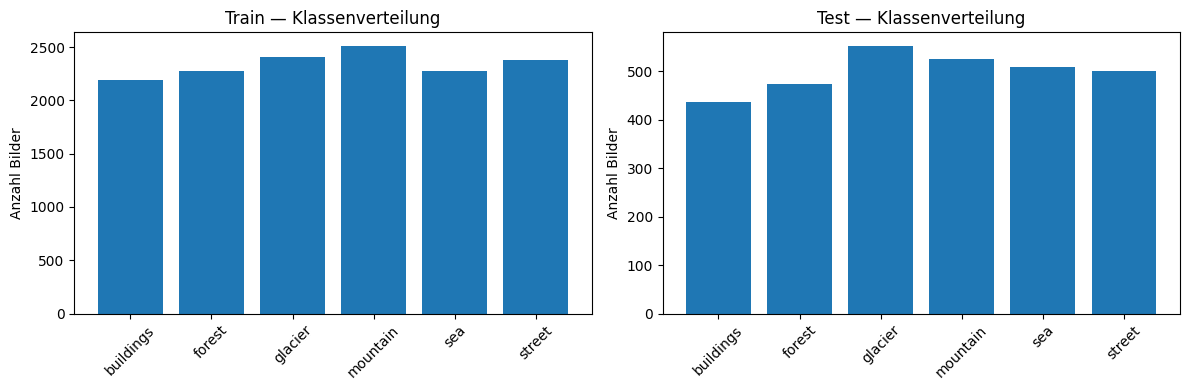

In [3]:
# Klassenverteilung im Train- und Test-Split
label_names = dataset["train"].features["label"].names
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

dist_df = pd.DataFrame(
    {"Klasse": label_names, "Train": train_counts.values, "Test": test_counts.values}
)
dist_df["Train %"] = (dist_df["Train"] / dist_df["Train"].sum() * 100).round(1)
dist_df["Test %"] = (dist_df["Test"] / dist_df["Test"].sum() * 100).round(1)
print(dist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(label_names, train_counts.values)
axes[0].set_title("Train — Klassenverteilung")
axes[0].set_ylabel("Anzahl Bilder")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(label_names, test_counts.values)
axes[1].set_title("Test — Klassenverteilung")
axes[1].set_ylabel("Anzahl Bilder")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Fazit Klassenverteilung

Sowohl das Train als auch das Test Datafram hat eine ausgewogene Klassenverteilung. Es benötigt keine Oversampling oder Undersampling einer Klasse.

- Train Dataset: 
  - Die `mountain` Klasse hat am meisten Vorkommnisse mit knapp unter 2500 Bilder. 
  - Die `buildings` Klasse und die `sea` Klasse haben am wenigsten ausprägungen mit ca. 2200 ausprägungen.
- Test Dataset:
  - Die `glacier` Klasse hat am meisten ausprägungen mit ca. 560 Bilder.
  - Die `buildings` Klasse hat am wenigsten ausprägungen mit 440 Bildern. 

Bei der Evaluation von dem Modellen werde ich beachten ob die kleineren Klassendichten bei `buildings` und `sea` einen Einfluss auf deren Performance haben durch Klassenbezogene Metriken (Precicion, Recall und F1). 

### Beispielbilder

Je 2 Beispielbilder pro Klasse zur visuellen Inspektion.

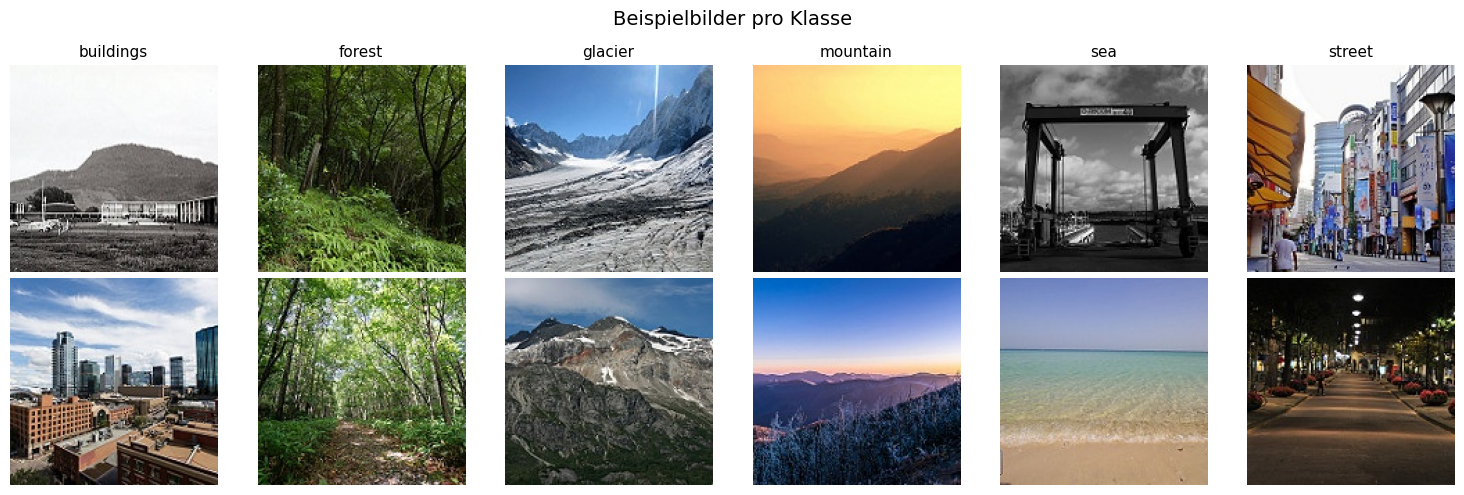

In [4]:
# Beispielbilder pro Klasse anzeigen
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle("Beispielbilder pro Klasse", fontsize=14)

for class_idx, class_name in enumerate(label_names):
    class_samples = dataset["train"].filter(lambda x: x["label"] == class_idx)
    for row in range(2):
        ax = axes[row, class_idx]
        ax.imshow(class_samples[row]["image"])
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=11)

plt.tight_layout()
plt.show()

### Fazit Beispielbilder pro Klasse

Meine vorhersage für die Modelle ist: 
- Die Klasse `forest` wird wahrscheinlich am einfachstenzu unterscheiden sein. 
- Die Klassen `buildings` und `street` könnten Problematisch zu unterscheiden sein. Bei dem ersten Beispielbild von `street` sieht man auch Gebäude was schwer zu unterscheiden sein kann für das Modell.
- Auch die Klassen `glacier` und `mountain` können schwer vorhersagbar sein für das Modell, da bei den `glacier` Beispielbildern auch Berge zu sehen sind. 
- Bei dem ersten Beispielbild von `sea` ist zu erkennen, dass der Datensatz auch Schwarz-Weiss Bilder enthält. Das Modell kann sich somit nicht lediglich auf die Farbkanäle verlassen. 

### Bildgrössen und Pixelwerte

Prüfen, ob alle Bilder die gleiche Grösse haben und wie der Wertebereich aussieht.

In [5]:
# Bildgrössen in allen Splits prüfen
train_sizes = [dataset["train"][i]["image"].size for i in range(len(dataset["train"]))]
test_sizes = [dataset["test"][i]["image"].size for i in range(len(dataset["test"]))]

unique_train_sizes = set(train_sizes)
unique_test_sizes = set(test_sizes)

print(f"Einzigartige Bildgrössen im Train-Split: {unique_train_sizes}")
print(f"Einzigartige Bildgrössen im Test-Split:  {unique_test_sizes}")

sample_img = dataset["train"][0]["image"]
img_array = np.array(sample_img)
print(f"\nShape eines Beispielbildes: {img_array.shape}")
print(f"Wertebereich: [{img_array.min()}, {img_array.max()}]")
print(f"Dtype: {img_array.dtype}")

Einzigartige Bildgrössen im Train-Split: {(150, 136), (150, 81), (150, 145), (150, 142), (150, 105), (150, 102), (150, 108), (150, 111), (150, 120), (150, 123), (150, 135), (150, 141), (150, 144), (150, 150), (150, 147), (150, 110), (150, 113), (150, 119), (150, 131), (150, 76), (150, 134), (150, 140), (150, 143), (150, 146), (150, 149), (150, 100), (150, 97), (150, 103), (150, 115), (150, 124), (150, 133)}
Einzigartige Bildgrössen im Test-Split:  {(150, 149), (150, 110), (150, 81), (150, 141), (150, 131), (150, 76), (150, 150), (150, 72)}

Shape eines Beispielbildes: (150, 150, 3)
Wertebereich: [0, 255]
Dtype: uint8


### Fazit Bildgrössen

Die Bilddimensionen sind in der Höhe immer 150 pixel. In der Breite variieren die Bilder jedoch. Im Trainings Datensatz ist die Bildbreite zwischen 81 pixel und 150 pixel. Im Test Datensatz sind die Bildbreiten zwischen 72 pixel und 150 pixeln. 

Dies muss bei dem Preprocessing Berücksichtigt werden. 

### Pixelwert-Verteilung pro Kanal pro Klasse

Boxplot der mittleren Pixelwerte pro RGB-Kanal, aufgeschlüsselt nach Klasse (je 200 Bilder pro Klasse). So lässt sich erkennen, ob bestimmte Klassen systematisch andere Farbverteilungen aufweisen.

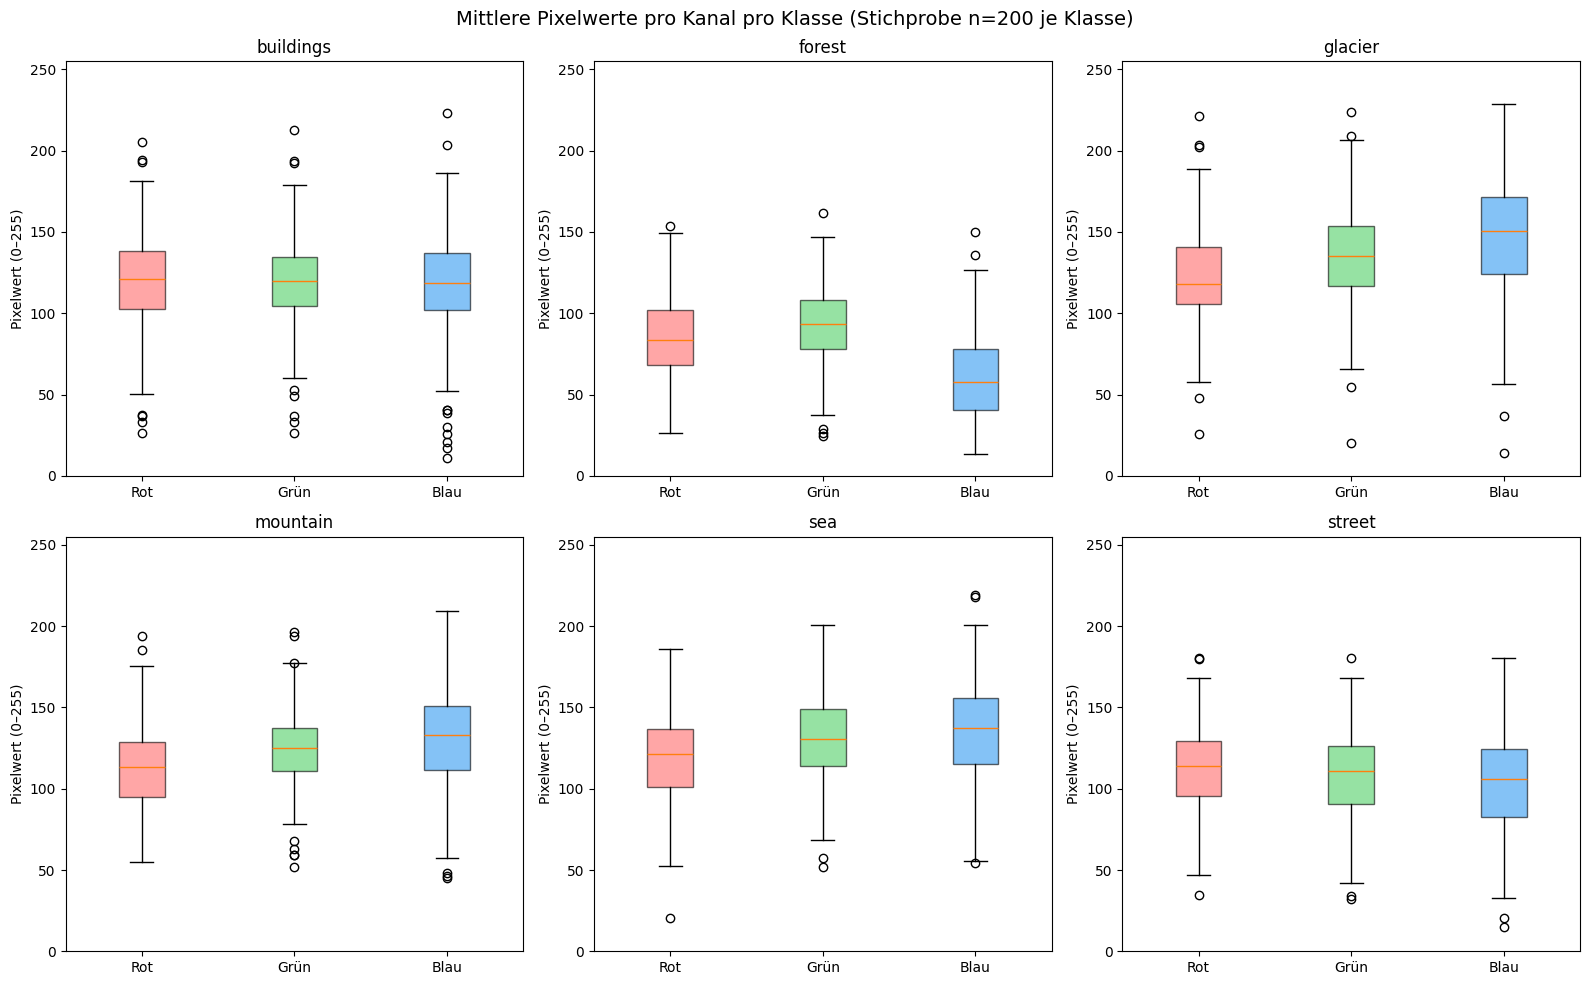


Klasse              R        G        B
--------------------------------------
buildings       118.8    119.4    118.1
forest           84.9     92.3     60.7
glacier         120.4    134.2    146.1
mountain        113.4    124.6    131.2
sea             119.0    129.4    136.8
street          111.5    107.5    103.6


In [6]:
# Pixelwert-Verteilung pro Kanal pro Klasse
rng = np.random.default_rng(RANDOM_SEED)
n_samples_per_class = 200
all_labels = dataset["train"]["label"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Mittlere Pixelwerte pro Kanal pro Klasse (Stichprobe n=200 je Klasse)", fontsize=14
)

summary = {}

for class_idx, class_name in enumerate(label_names):
    ax = axes[class_idx // 3, class_idx % 3]

    class_indices = [i for i, lbl in enumerate(all_labels) if lbl == class_idx]
    sample_indices = rng.choice(
        class_indices, size=min(n_samples_per_class, len(class_indices)), replace=False
    )

    pixel_data = {"R": [], "G": [], "B": []}
    for idx in sample_indices:
        img = np.array(dataset["train"][int(idx)]["image"])
        for c, name in enumerate(["R", "G", "B"]):
            pixel_data[name].append(img[:, :, c].mean())

    summary[class_name] = pixel_data

    bp = ax.boxplot(
        [pixel_data["R"], pixel_data["G"], pixel_data["B"]],
        tick_labels=["Rot", "Grün", "Blau"],
        patch_artist=True,
    )
    colors = ["#FF6B6B", "#51CF66", "#339AF0"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(class_name, fontsize=12)
    ax.set_ylabel("Pixelwert (0–255)")
    ax.set_ylim(0, 255)

plt.tight_layout()
plt.show()

# Zusammenfassung: Mittelwerte pro Klasse und Kanal
print(f"\n{'Klasse':<12} {'R':>8} {'G':>8} {'B':>8}")
print("-" * 38)
for class_name, data in summary.items():
    print(
        f"{class_name:<12} {np.mean(data['R']):>8.1f} {np.mean(data['G']):>8.1f} {np.mean(data['B']):>8.1f}"
    )

### Fazit der mittleren Farbkanalwerte pro Klasse
**Beobachtungen:**

- `forest` ist die am einfachsten unterscheidbare Klasse: Sie hat die niedrigste Gesamthelligkeit und eine Grün Dominanz. Der blaue Kanal ist mit 60.7 der niedrigste Wert im gesamten Datensatz.
- `glacier`, `mountain` und `sea` bilden ein problematisches Cluster. Alle drei Klassen sind blau dominant und liegen in der Gesamthelligkeit nahe beieinander. Die Farbinformation allein reicht hier nicht aus, um zuverlässig zwischen diesen Klassen zu unterscheiden.
- `buildings` zeigt ein nahezu perfekt neutrales Farbprofil. Rot, Grün und Blau sind sehr ausgeglichen. 
- `street` ist ebenfalls relativ ausgeglichen, wobei rot am dominantesten ist. Die `street` Pixelverteilung ist dazu noch leicht tiefer (dünkler) als die `buildings` Pixelwerte

**Implikationen für das Modell:**

1. **Farbinformation ist notwendig, aber nicht hinreichend.** Während Forest anhand der Farbverteilung gut trennbar ist, muss das CNN für die Unterscheidung von Glacier/Mountain/Sea auf **Textur- und Strukturmerkmale** (Kanten, Muster, räumliche Frequenzen) zurückgreifen. Das zeigt, wie wichtig die Convolutional Layers sind.
2. **Normalisierung ist wichtig.** Die Mittelwerte weichen deutlich von 128 (Mitte des [0, 255]-Bereichs) ab und unterscheiden sich zwischen den Kanälen. Eine kanalweise Normalisierung (z.B. mit den berechneten Mittelwerten und Standardabweichungen) hilft dem Modell, schneller zu konvergieren, da die Eingabedaten zentriert und skaliert werden.
3. **Verwechslungsrisiken** sind vorhersehbar: Die Confusion Matrix wird vermutlich erhöhte Verwechslungsraten zwischen Glacier ↔ Mountain ↔ Sea sowie zwischen Buildings ↔ Street zeigen. Dies haben ich bereits in den Beispielbildern zum Teil vorhergesagt. 

## Preprocessing

### Train/Validation-Split und Kanal-Statistiken berechnen

Zuerst wird der Train/Validation-Split (80/20, stratifiziert) durchgeführt. Danach werden Mittelwerte und Standardabweichungen pro RGB-Kanal **ausschliesslich über den Trainings-Split** berechnet, nicht über den gesamten Datensatz, um Data Leakage zu vermeiden.

Der Validation Split entsteht aus 20% von den vorgegebenen trainings Datensatz. 
- `train`:        80% von dem **Train** Datensatz
- `validation`:   20% von dem **Train** Datensatz
- `test`:         100% von dem **Test** Datensatz

In [7]:
# Train/Validation-Split zuerst, damit Kanal-Statistiken nur auf Trainingsdaten berechnet werden
train_indices, val_indices = train_test_split(
    range(len(dataset["train"])),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=dataset["train"]["label"],
)

# Kanal-Mittelwerte und Standardabweichungen NUR über den Train-Split berechnen
# Validation- und Test-Daten dürfen nicht einfliessen (Data Leakage)
channel_sum = np.zeros(3)
channel_sq_sum = np.zeros(3)
n_pixels = 0

for i in train_indices:
    img = np.array(dataset["train"][i]["image"], dtype=np.float32) / 255.0
    channel_sum += img.sum(axis=(0, 1))
    channel_sq_sum += (img**2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

channel_mean = channel_sum / n_pixels
channel_std = np.sqrt(channel_sq_sum / n_pixels - channel_mean**2)

print(f"Train-Split: {len(train_indices)} Bilder, Val-Split: {len(val_indices)} Bilder")
print(f"Channel means (nur Train-Split): {channel_mean}")
print(f"Channel stds  (nur Train-Split): {channel_std}")

Train-Split: 11227 Bilder, Val-Split: 2807 Bilder
Channel means (nur Train-Split): [0.43018795 0.45737195 0.45355669]
Channel stds  (nur Train-Split): [0.26945614 0.26800597 0.29854997]


### Transform-Pipeline

**Train Pipeline**
- `RandomResizedCrop` (64x64) für Training: Aus den ~150x150 Bildern wird pro Aufruf ein zufälliger 64x64-Ausschnitt genommen. Der Ausschnitt darf zwischen 40% und 100% gross sein. Das wirkt als Data Augmentation.
- `RandomHorizontalFlip` Die Bilder werden mit einer Wahrscheinlichkeit von 50% Horizontal geflipped. Das macht das Modell robuster. 
- `ToTensor` wandelt die Bilder von einem PIL-Bild zu einem PyTorch-Tensor um. Dabei wird:
  - Wertebereich von 0–255 auf 0–1 skaliert
  - Format wird von HWC (64, 64, 3) zu CHW (3, 64, 64) geändert
- `Normalize` Hier werden die Pixelwerte pro Farbkanal normalisiert.
  - $x_{neu} = \frac{x - \text{mean}}{\text{std}}$

**Validation und Test Pipeline**
- `Resize` (64x64): Das gesamte Bild wird auf 64x64 herunter skaliert, damit keine Bildinformation durch Cropping verloren geht und die Evaluation auf dem vollständigen Bildinhalt basiert.

In [8]:
# Train: RandomResizedCrop + HorizontalFlip als Data Augmentation
transform_train = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            64, scale=(0.4, 1.0)
        ),  # TODO Fragen ob bei Etappe bereits erlaubt ist.
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),  # PIL -> Tensor [0,1], HWC -> CHW
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)


# Validation/Test: CenterCrop für deterministische Evaluation
transform_eval = transforms.Compose(
    [
        transforms.Resize((64, 64)),  # Beide Dimensionen auf 64x64 erzwingen
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

### PyTorch Dataset-Wrapper

Wrapper-Klasse, die das HuggingFace Dataset in ein PyTorch Dataset konvertiert und den Transform anwendet.

In [9]:
# PyTorch Dataset-Wrapper für HuggingFace Dataset
class IntelImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

### Train/Validation/Test-Split

train_indices und val_indices wurden bereits oben erstellt (80/20, stratifiziert). Hier werden die HuggingFace-Subsets und PyTorch Datasets daraus erzeugt. Das Testset bleibt unverändert.

In [10]:
# train_indices und val_indices wurden oben bei der Kanal-Statistik-Berechnung erstellt
hf_train = dataset["train"].select(train_indices)
hf_val = dataset["train"].select(val_indices)

train_dataset = IntelImageDataset(hf_train, transform=transform_train)
val_dataset = IntelImageDataset(hf_val, transform=transform_eval)
test_dataset = IntelImageDataset(dataset["test"], transform=transform_eval)

print(f"Train:      {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test:       {len(test_dataset)} Bilder")

Train:      11227 Bilder
Validation: 2807 Bilder
Test:       3000 Bilder


### DataLoaders erstellen

DataLoader für Train, Validation und Test mit initialer Batch-Size von 64. Sanity Check der Batch-Dimensionen und Pixelwerte.

In [11]:
# DataLoaders erstellen
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check: ein Batch laden
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [64, 3, 150, 150]
print(f"Labels shape: {labels.shape}")  # [64]
print(f"Pixel range:  [{images.min():.2f}, {images.max():.2f}]")

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])
Pixel range:  [-1.71, 2.11]


## Schritt 1: Setup (Device, Metriken, W&B)

Als Kostenfunktion (Loss-Funktion) wird `CrossEntropyLoss` verwendet. `CrossEntropyLoss` wird verwendet, weil das Modell Bilder mehreren möglichen Klassen zuordnen soll, wobei jedes Bild genau eine richtige Klasse besitzt. Die Funktion misst, wie gut die Vorhersage des Modells mit dem tatsächlichen Klassenlabel übereinstimmt, und eignet sich deshalb gut für Multiclass-Classification.

In [12]:
# Device Setup (Apple Silicon MPS / CUDA / CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Kostenfunktion
criterion = nn.CrossEntropyLoss()

# Klassennamen
NUM_CLASSES = 6
CLASS_NAMES = dataset["train"].features["label"].names
print(f"Klassen ({NUM_CLASSES}): {CLASS_NAMES}")

Device: mps
Klassen (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### W&B Login

Authentifizierung bei Weights & Biases für Experiment-Tracking.

In [13]:
# W&B Login
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/lucamanna/.netrc.
wandb: Currently logged in as: mannaluca02 (mannaluca02-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Schritt 2: Training- und Evaluierungsfunktionen

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Trainiert eine Epoche. Gibt (loss, accuracy) zurück."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()  # entfernt alte Gradienten
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(dim=1) == Y).sum().item()
        total += Y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluiert das Modell. Gibt (loss, accuracy) zurück."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Keine Gradientenberechnung für Evaluation
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            total_loss += criterion(pred, Y).item()
            correct += (pred.argmax(dim=1) == Y).sum().item()
            total += Y.size(0)

    return total_loss / len(loader), correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    log_wandb=True,
):
    """Kompletter Trainingsloop mit optionalem W&B-Logging. Gibt History-Dict zurück."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if log_wandb:
            wandb.log(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                }
            )

        print(
            f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
        )

    elapsed = time.time() - start_time
    minutes, seconds = divmod(elapsed, 60)
    print(
        f"\nTraining abgeschlossen in {int(minutes)}m {seconds:.1f}s ({epochs} Epochen, {elapsed/epochs:.2f}s/Epoche)"
    )

    return history


def plot_training(history, title="Lernkurven"):
    """Plottet Loss und Accuracy (Train vs Val). Gibt die Figure zurück."""
    epochs = range(len(history["train_loss"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-", label="Train")
    ax1.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], "b-", label="Train")
    ax2.plot(epochs, history["val_acc"], "r-", label="Validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

### Evaluierungs- und Visualisierungsfunktionen

- **Lernkurven** (Train Loss / Val Loss / Train Accuracy / Val Accuracy): wie sich das Modell über die Epochen entwickelt.
- **Generalization Gap**: zeigt direkt den Unterschied zwischen Trainings- und Validierungsleistung.
- **Confusion Matrix**: Sie zeigt für jede Klasse:
  - wie oft sie korrekt erkannt wurde
  - mit welchen anderen Klassen sie verwechselt wurde
- **Per-Class Metrics**: Balkendiagramm pro Klasse mit folgenden Werten:
  - Precision
  - Recall
  - F1-Score
- **Top-Loss Samples**: Zeigt die Beispiele bei denen das Modell die grössten Schwierigkeiten hatte.
- **Cross-Validation Boxplot**: wie stabil das Modell über verschiedene Folds hinweg performt.


In [34]:
def denormalize(tensor, mean, std):
    """Denormalisiert einen Bild-Tensor für die Anzeige."""
    mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
    std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def collect_predictions(model, loader, device):
    """Sammelt Bilder, Predictions, Labels und Per-Sample-Losses vom gesamten Loader."""
    model.eval()
    all_images, all_labels, all_preds, all_probs, all_losses = [], [], [], [], []
    with torch.no_grad():
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            probs = torch.softmax(logits, dim=1)
            losses = F.cross_entropy(logits, Y, reduction="none")
            all_images.append(X.cpu())
            all_labels.append(Y.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_probs.append(probs.cpu())
            all_losses.append(losses.cpu())
    return {
        "images": torch.cat(all_images),
        "y_true": torch.cat(all_labels).numpy(),
        "y_pred": torch.cat(all_preds).numpy(),
        "y_probs": torch.cat(all_probs).numpy(),
        "losses": torch.cat(all_losses).numpy(),
    }


def plot_cv_boxplot(fold_results, title="Cross-Validation Accuracy"):
    """Box-Plot und Einzelwerte der Cross-Validation Ergebnisse."""
    best_accs = [r["best_val_acc"] for r in fold_results]
    final_accs = [r["final_val_acc"] for r in fold_results]

    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(
        [best_accs, final_accs],
        tick_labels=["Best Val Acc", "Final Val Acc"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#2196F3")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("#FF9800")
    bp["boxes"][1].set_alpha(0.6)

    for i, data in enumerate([best_accs, final_accs], 1):
        ax.scatter([i] * len(data), data, color="black", zorder=5, s=50)
        for j, val in enumerate(data):
            ax.annotate(f"  Fold {j + 1}", (i, val), fontsize=8, va="center")

    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
    return fig


def evaluate_model(
    model,
    loader,
    class_names,
    device,
    mean,
    std,
    top_n_loss=16,
    log_wandb=True,
):
    """Sammelt Predictions und loggt alle Rohdaten zu W&B, damit Confusion Matrix,
    Per-Class Metrics und Top-Loss Samples im W&B-Report interaktiv dargestellt werden.
    Erzeugt keine Plots im Notebook."""
    results = collect_predictions(model, loader, device)
    y_true = results["y_true"]
    y_pred = results["y_pred"]

    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    acc = float(np.mean(y_true == y_pred))

    if log_wandb and wandb.run is not None:
        # Confusion Matrix — native interaktiv via wandb.plot.confusion_matrix
        wandb.log(
            {
                "eval/confusion_matrix": wandb.plot.confusion_matrix(
                    y_true=y_true, preds=y_pred, class_names=class_names
                )
            }
        )

        # Drei separate native Bar-Charts via wandb.plot.bar.
        # Enthalten alle Klassen + macro/weighted avg als Summary-Rows.
        groups = list(class_names) + ["macro avg", "weighted avg"]
        bar_panels = {}
        for metric, panel_key, title in [
            ("precision", "eval/per_class_precision", "Per-Class Precision"),
            ("recall", "eval/per_class_recall", "Per-Class Recall"),
            ("f1-score", "eval/per_class_f1", "Per-Class F1-Score"),
        ]:
            tbl = wandb.Table(
                columns=["class", metric],
                data=[[g, float(report[g][metric])] for g in groups],
            )
            bar_panels[panel_key] = wandb.plot.bar(tbl, "class", metric, title=title)
        wandb.log(bar_panels)

        # Classification Report als flache Tabelle (für Detail-Ansicht im Report)
        wandb.log(
            {
                "eval/classification_report": wandb.Table(
                    columns=["class", "precision", "recall", "f1-score", "support"],
                    data=[
                        [
                            name,
                            report[name]["precision"],
                            report[name]["recall"],
                            report[name]["f1-score"],
                            int(report[name]["support"]),
                        ]
                        for name in class_names
                    ],
                ),
                "eval/accuracy": acc,
            }
        )

        # Top-Loss Samples als Table mit Bildern → sortierbares Panel im Report
        top_idx = np.argsort(results["losses"])[-top_n_loss:][::-1]
        top_loss_table = wandb.Table(
            columns=["image", "true", "pred", "confidence", "loss"]
        )
        for idx in top_idx:
            img = (
                denormalize(results["images"][idx], mean, std).permute(1, 2, 0).numpy()
            )
            top_loss_table.add_data(
                wandb.Image(img),
                class_names[int(y_true[idx])],
                class_names[int(y_pred[idx])],
                float(results["y_probs"][idx][int(y_pred[idx])]),
                float(results["losses"][idx]),
            )
        wandb.log({"eval/top_loss_samples": top_loss_table})

    print(f"\nGesamtgenauigkeit: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return results

### Hyperparameter-Vergleichs-Visualisierungen

- **Vergleichsplot für Loss und Accuracy**: zeigt, wie sich verschiedene Hyperparameterwerte über die Epochen hinweg auf Trainings- und Validierungsleistung auswirken.
- **Beste Validation Accuracy pro Hyperparameterwert**: Balkendiagramm, das den besten erreichten Validierungswert pro getesteter Konfiguration darstellt.
- **Generalization Gap im Hyperparametervergleich**: zeigt für verschiedene Hyperparameterwerte den Unterschied zwischen Validierungs- und Trainings-Loss und hilft, Overfitting zu erkennen.

In [16]:
def plot_hp_comparison(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Vergleichsplot: Train (solid) + Val (gestrichelt) fuer Loss und Accuracy."""
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(histories)))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for (hp_val, hist), color in zip(histories.items(), colors):
        epochs = range(len(hist["train_loss"]))
        ax1.plot(
            epochs,
            hist["train_loss"],
            "-",
            color=color,
            alpha=0.7,
            label=f"{hp_name}={hp_val}",
        )
        ax1.plot(epochs, hist["val_loss"], "--", color=color, alpha=0.7)
        ax2.plot(
            epochs,
            hist["train_acc"],
            "-",
            color=color,
            alpha=0.7,
            label=f"{hp_name}={hp_val}",
        )
        ax2.plot(epochs, hist["val_acc"], "--", color=color, alpha=0.7)

    # Linestyle-Legende: solid=Train, dashed=Validation
    style_handles = [
        Line2D([0], [0], color="gray", linestyle="-", label="Train"),
        Line2D([0], [0], color="gray", linestyle="--", label="Validation"),
    ]

    for ax, ylabel, title_suffix in [
        (ax1, "Loss", "Loss"),
        (ax2, "Accuracy", "Accuracy"),
    ]:
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{hp_label}-Tuning — {title_suffix}")
        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles=handles + style_handles, fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_hp_best_accuracy(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Balkendiagramm: Beste Validation Accuracy pro HP-Wert mit Epoche."""
    hp_vals = list(histories.keys())
    best_accs = [max(h["val_acc"]) for h in histories.values()]
    best_epochs = [int(np.argmax(h["val_acc"])) for h in histories.values()]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(range(len(hp_vals)), best_accs, color="#2196F3", alpha=0.8)
    ax.set_xticks(range(len(hp_vals)))
    ax.set_xticklabels([f"{hp_name}={v}" for v in hp_vals], rotation=45, ha="right")
    ax.set_ylabel("Best Validation Accuracy")
    ax.set_title(f"{hp_label}-Tuning — Beste Validation Accuracy")
    ax.set_ylim(min(best_accs) - 0.05, max(best_accs) + 0.03)
    ax.grid(True, alpha=0.3, axis="y")

    for bar, acc, epoch in zip(bars, best_accs, best_epochs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{acc:.3f}\n(Ep. {epoch})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # Besten Balken hervorheben
    best_idx = int(np.argmax(best_accs))
    bars[best_idx].set_color("#4CAF50")

    plt.tight_layout()
    plt.show()
    return fig


def plot_hp_gap_comparison(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Generalization Gap (Val Loss - Train Loss) im Vergleich ueber mehrere HP-Werte."""
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(histories)))
    fig, ax = plt.subplots(figsize=(10, 5))

    for (hp_val, hist), color in zip(histories.items(), colors):
        epochs = range(len(hist["train_loss"]))
        gap = [v - t for t, v in zip(hist["train_loss"], hist["val_loss"])]
        ax.plot(epochs, gap, color=color, linewidth=1.5, label=f"{hp_name}={hp_val}")

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss - Train Loss")
    ax.set_title(f"{hp_label}-Tuning — Generalization Gap")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

### Cross-Validation-Visualisierungen

- **Mean ± Std Band für Loss und Accuracy**: zeigt den durchschnittlichen Trainings- und Validierungsverlauf über alle Folds hinweg sowie die Streuung der Ergebnisse.
- **Per-Class Accuracy pro Fold**: gruppiertes Balkendiagramm, das die Accuracy jeder Klasse für jeden einzelnen Fold darstellt.
- **Mean ± Std der Per-Class Accuracy**: ergänzt die klassenweisen Fold-Ergebnisse durch den Mittelwert und die Standardabweichung, um die Stabilität der Klassenleistung über alle Folds hinweg sichtbar zu machen.

In [17]:
def plot_cv_mean_std_band(fold_results, title_prefix="Cross-Validation"):
    """Mean +/- Std Band ueber alle Folds fuer Loss und Accuracy."""
    n_epochs = min(len(r["history"]["val_loss"]) for r in fold_results)

    # Sammle Metriken pro Epoche
    val_losses = np.array([r["history"]["val_loss"][:n_epochs] for r in fold_results])
    val_accs = np.array([r["history"]["val_acc"][:n_epochs] for r in fold_results])
    train_losses = np.array(
        [r["history"]["train_loss"][:n_epochs] for r in fold_results]
    )
    train_accs = np.array([r["history"]["train_acc"][:n_epochs] for r in fold_results])
    epochs = np.arange(n_epochs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    for data, color, label in [
        (train_losses, "#2196F3", "Train"),
        (val_losses, "#E53935", "Validation"),
    ]:
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        ax1.plot(epochs, mean, color=color, linewidth=2, label=f"{label} (Mean)")
        ax1.fill_between(
            epochs,
            mean - std,
            mean + std,
            color=color,
            alpha=0.15,
            label=f"{label} (±1 Std)",
        )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title_prefix} — Loss (Mean ± Std)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Accuracy
    for data, color, label in [
        (train_accs, "#2196F3", "Train"),
        (val_accs, "#E53935", "Validation"),
    ]:
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        ax2.plot(epochs, mean, color=color, linewidth=2, label=f"{label} (Mean)")
        ax2.fill_between(
            epochs,
            mean - std,
            mean + std,
            color=color,
            alpha=0.15,
            label=f"{label} (±1 Std)",
        )

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title_prefix} — Accuracy (Mean ± Std)")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_cv_per_class_accuracy(
    fold_predictions,
    class_names,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
):
    """Gruppiertes Balkendiagramm: Accuracy pro Klasse, aufgeschluesselt nach Fold."""
    n_folds = len(fold_predictions)
    n_classes = len(class_names)

    # Per-Class Accuracy pro Fold berechnen
    per_class_accs = np.zeros((n_folds, n_classes))
    for f_idx, pred in enumerate(fold_predictions):
        for c_idx in range(n_classes):
            mask = pred["y_true"] == c_idx
            if mask.sum() > 0:
                per_class_accs[f_idx, c_idx] = (pred["y_pred"][mask] == c_idx).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(n_classes)
    width = 0.8 / n_folds

    for f_idx in range(n_folds):
        offset = (f_idx - n_folds / 2 + 0.5) * width
        ax.bar(
            x + offset,
            per_class_accs[f_idx],
            width,
            label=f"Fold {f_idx + 1}",
            alpha=0.8,
        )

    # Mean + Std als Fehlerbalken
    mean_accs = per_class_accs.mean(axis=0)
    std_accs = per_class_accs.std(axis=0)
    ax.errorbar(
        x,
        mean_accs,
        yerr=std_accs,
        fmt="ko",
        capsize=5,
        capthick=2,
        linewidth=0,
        elinewidth=2,
        label="Mean ± Std",
        zorder=5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    return fig

## Schritt 3: CNN-Basismodell

Architektur für 64x64x3 Bilder (Resize zur Verkürzung der Trainingszeit):
- 3 Conv-Blöcke (Conv2d + ReLU + MaxPool2d) für Feature-Extraktion
- 2 Fully Connected Layers für Klassifikation
- Kein Dropout, kein BatchNorm (Vorgabe Stage 1)
- Output: raw logits (CrossEntropyLoss enthält Softmax)
- Die Linear-Layer-Grösse wird automatisch aus der Bildgrösse berechnet

In [18]:
IMG_SIZE = 64  # Muss mit transforms.Resize übereinstimmen


class BaseCNN(nn.Module):
    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Feature-Map-Grösse nach 3x MaxPool2d(2)
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Modell instanzieren und Architektur prüfen
model = BaseCNN(NUM_CLASSES).to(device)
print(model)
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")

# Forward-Pass Test mit aktueller Bildgrösse
with torch.no_grad():
    test_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    test_output = model(test_input)
    print(f"\nInput:  {test_input.shape}")
    print(f"Output: {test_output.shape}")  # Erwartet: [2, 6]

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Parameter: 548,774

Input:  torch.Size([2, 3, 64, 64])
Output: torch.Size([2, 6])


## Schritt 4: Overfitting-Test

Laut Aufgabenstellung (Punkt 3d): Trainiere auf einem einzelnen Batch. Der Loss muss gegen 0 gehen. Das bestätigt, dass Modell und Training-Loop korrekt funktionieren.

Epoch   0 | Train Loss: 1.7908  Acc: 0.1719 | Val Loss: 1.7854  Acc: 0.1719
Epoch   1 | Train Loss: 1.7854  Acc: 0.1719 | Val Loss: 1.7804  Acc: 0.2031
Epoch   2 | Train Loss: 1.7804  Acc: 0.2031 | Val Loss: 1.7757  Acc: 0.2500
Epoch   3 | Train Loss: 1.7757  Acc: 0.2500 | Val Loss: 1.7712  Acc: 0.2500
Epoch   4 | Train Loss: 1.7712  Acc: 0.2500 | Val Loss: 1.7665  Acc: 0.2344
Epoch   5 | Train Loss: 1.7665  Acc: 0.2344 | Val Loss: 1.7616  Acc: 0.2344
Epoch   6 | Train Loss: 1.7616  Acc: 0.2344 | Val Loss: 1.7568  Acc: 0.2344
Epoch   7 | Train Loss: 1.7568  Acc: 0.2344 | Val Loss: 1.7519  Acc: 0.2344
Epoch   8 | Train Loss: 1.7519  Acc: 0.2344 | Val Loss: 1.7469  Acc: 0.2344
Epoch   9 | Train Loss: 1.7469  Acc: 0.2344 | Val Loss: 1.7416  Acc: 0.2344
Epoch  10 | Train Loss: 1.7416  Acc: 0.2344 | Val Loss: 1.7360  Acc: 0.2344
Epoch  11 | Train Loss: 1.7360  Acc: 0.2344 | Val Loss: 1.7302  Acc: 0.2344
Epoch  12 | Train Loss: 1.7302  Acc: 0.2344 | Val Loss: 1.7242  Acc: 0.2344
Epoch  13 | 

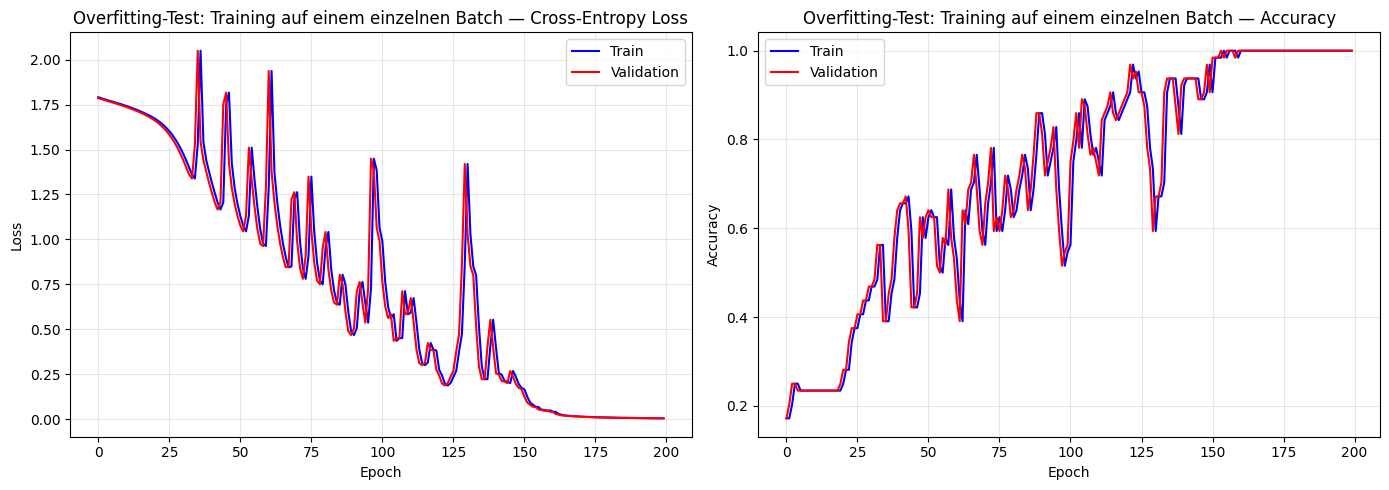


Final Loss: 0.004796 | Final Acc: 1.0000
BESTANDEN — Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt.


In [19]:
# Overfitting-Test: ein einzelner Batch, 200 Iterationen mit höherer LR
# Verwendet train_model() und evaluate(), um gleichzeitig den Training-Loop zu validieren.

overfit_model = BaseCNN(NUM_CLASSES).to(device)
overfit_optimizer = optim.SGD(overfit_model.parameters(), lr=0.05)

# Einen Batch extrahieren und als DataLoader wrappen
single_batch_X, single_batch_Y = next(iter(train_loader))
single_batch_dataset = TensorDataset(single_batch_X, single_batch_Y)
single_batch_loader = DataLoader(single_batch_dataset, batch_size=len(single_batch_X))

# 200 Epochs = 200 Iterationen (Loader enthält nur 1 Batch)
history_overfit = train_model(
    overfit_model,
    single_batch_loader,
    single_batch_loader,  # Val = gleicher Batch (Overfitting-Test)
    criterion,
    overfit_optimizer,
    device,
    epochs=200,
    log_wandb=False,
)

plot_training(
    history_overfit, title="Overfitting-Test: Training auf einem einzelnen Batch"
)

final_loss = history_overfit["train_loss"][-1]
final_acc = history_overfit["train_acc"][-1]
print(f"\nFinal Loss: {final_loss:.6f} | Final Acc: {final_acc:.4f}")
if final_loss < 0.01 and final_acc > 0.99:
    print(
        "BESTANDEN — Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt."
    )
else:
    print("NICHT BESTANDEN — Loss konvergiert nicht gegen 0.")

### Beobachtungen Overfitting-Test

**Train vs. Validation identisch:** Da beide Kurven auf exakt denselben Daten operieren (gleicher DataLoader für Train und Validation), liegen sie nahezu perfekt übereinander. Der minimale Unterschied entsteht dadurch, dass `train_epoch()` im `model.train()`-Modus läuft und die Metriken **während** des Gradientenupdates berechnet (der Loss am Anfang des Batches, bevor die Gewichte aktualisiert werden), während `evaluate()` im `model.eval()`-Modus die Metriken **nach** dem Update berechnet. Daher ist die rote Validation-Kurve immer minimal besser als die blaue Train-Kurve.


**Spikes im Verlauf:** Die Spikes entstehen durch die Kombination aus hoher Lernrate (0.05) und SGD ohne Momentum auf nur einem einzigen Batch. Bei einem einzelnen Batch von 64 Bildern ist die Loss-Landschaft nicht glatt, sondern hat krümmungen. Mit `lr=0.05` sind die Gradientenschritte gross genug, um über ein lokales Minimum hinauszuschiessen und in einen Bereich mit höherem Loss zu springen. Das Modell "springt" dann wieder zurück, was die wiederholten Spikes erklärt.

Der Gesamttrend ist klar abwärts, und ab ca. Epoch 150 konvergiert der Loss stabil gegen 0. Die Spikes sind also kein Problem. Sie zeigen nur, dass die LR für diesen kleinen Datensatz aggressiv ist. Mit einer kleineren LR (z.B. 0.01) wären die Kurven glatter, aber die Konvergenz langsamer.

## Schritt 5: Basis-Training mit W&B

Training des Basismodells mit SGD (ohne Momentum), lr=0.05, 150 Epochs. W&B trackt alle Metriken.

In [20]:
# Basis-Training
run = wandb.init(
    project="del-mini-challenge",
    name="base-model-sgd-lr0.05",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": 0.05,
        "momentum": 0.0,
        "batch_size": BATCH_SIZE,
        "epochs": 150,
        "num_classes": NUM_CLASSES,
    },
)

model = BaseCNN(NUM_CLASSES).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.05)
wandb.watch(model, log="all")

history_base = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=150
)

Epoch   0 | Train Loss: 1.3832  Acc: 0.4544 | Val Loss: 1.1169  Acc: 0.5290
Epoch   1 | Train Loss: 1.0829  Acc: 0.5736 | Val Loss: 0.9766  Acc: 0.6245
Epoch   2 | Train Loss: 0.9948  Acc: 0.6129 | Val Loss: 0.9242  Acc: 0.6373
Epoch   3 | Train Loss: 0.9245  Acc: 0.6418 | Val Loss: 1.3101  Acc: 0.5444
Epoch   4 | Train Loss: 0.8629  Acc: 0.6723 | Val Loss: 0.8637  Acc: 0.6562
Epoch   5 | Train Loss: 0.8116  Acc: 0.6934 | Val Loss: 1.0080  Acc: 0.6323
Epoch   6 | Train Loss: 0.7734  Acc: 0.7106 | Val Loss: 0.6974  Acc: 0.7424
Epoch   7 | Train Loss: 0.7343  Acc: 0.7280 | Val Loss: 0.7639  Acc: 0.7253
Epoch   8 | Train Loss: 0.7134  Acc: 0.7373 | Val Loss: 0.7108  Acc: 0.7353
Epoch   9 | Train Loss: 0.6718  Acc: 0.7541 | Val Loss: 0.7336  Acc: 0.7089
Epoch  10 | Train Loss: 0.6789  Acc: 0.7525 | Val Loss: 0.7111  Acc: 0.7467
Epoch  11 | Train Loss: 0.6487  Acc: 0.7635 | Val Loss: 0.8216  Acc: 0.6961
Epoch  12 | Train Loss: 0.6146  Acc: 0.7735 | Val Loss: 0.6305  Acc: 0.7766
Epoch  13 | 

### Evaluation Basismodell

Vollständige Evaluation auf dem Validierungsset. Alle Rohdaten (Confusion Matrix, Per-Class Precision/Recall/F1, Top-Loss Samples inkl. Bilder) werden zu W&B geloggt und ausschliesslich im **W&B-Report** interaktiv dargestellt — im Notebook werden keine Plots mehr erzeugt.

In [21]:
# Vollständige Evaluation des Basismodells auf dem Validierungsset
# Rohdaten werden zu W&B geloggt; alle Visualisierungen im W&B-Report erzeugt.
results_base = evaluate_model(
    model,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

wandb.finish()


Gesamtgenauigkeit: 0.8393
              precision    recall  f1-score   support

   buildings       0.88      0.84      0.86       438
      forest       0.95      0.95      0.95       454
     glacier       0.77      0.75      0.76       481
    mountain       0.79      0.76      0.77       503
         sea       0.84      0.84      0.84       455
      street       0.82      0.92      0.87       476

    accuracy                           0.84      2807
   macro avg       0.84      0.84      0.84      2807
weighted avg       0.84      0.84      0.84      2807



epoch,▁▁▁▁▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
eval/accuracy,▁
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█▇▇█████████████████
train_loss,█▅▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▄▄▅▆▆▇▇▇▇█▇▁▇████▇██▇████████████████▇█
val_loss,▃▂▁▁▁▁█▂▂▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▁▂▁▂▂▃
epoch,149
eval/accuracy,0.83933
train_acc,0.94861
train_loss,0.15198
val_acc,0.83933


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Basis-modell-Report--VmlldzoxNjU5ODYwMQ" style="border:none;height:1024px;width:100%">

## Schritt 6: Lernraten-Tuning

Wir testen mehrere Lernraten (0.001, 0.005, 0.01, 0.05, 0.1) mit SGD ohne Momentum. Jedes Training wird als eigener W&B-Run geloggt. Anschliessend vergleichen wir die Lernkurven.

In [22]:
# LR-Tuning: mehrere Lernraten vergleichen
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_histories = {}
LR_EPOCHS = 100

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Training mit lr={lr}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"lr-tuning-{lr}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": lr,
            "momentum": 0.0,
            "batch_size": BATCH_SIZE,
            "epochs": LR_EPOCHS,
            "experiment": "lr-tuning",
        },
        reinit=True,
    )

    model_lr = BaseCNN(NUM_CLASSES).to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr)

    lr_histories[lr] = train_model(
        model_lr,
        train_loader,
        val_loader,
        criterion,
        optimizer_lr,
        device,
        epochs=LR_EPOCHS,
    )

    wandb.finish()


Training mit lr=0.001


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   0 | Train Loss: 1.7871  Acc: 0.1724 | Val Loss: 1.7828  Acc: 0.2280
Epoch   1 | Train Loss: 1.7785  Acc: 0.2449 | Val Loss: 1.7733  Acc: 0.2871
Epoch   2 | Train Loss: 1.7678  Acc: 0.3165 | Val Loss: 1.7605  Acc: 0.3459
Epoch   3 | Train Loss: 1.7524  Acc: 0.3521 | Val Loss: 1.7414  Acc: 0.3712
Epoch   4 | Train Loss: 1.7294  Acc: 0.3713 | Val Loss: 1.7122  Acc: 0.3794
Epoch   5 | Train Loss: 1.6947  Acc: 0.3716 | Val Loss: 1.6684  Acc: 0.3876
Epoch   6 | Train Loss: 1.6462  Acc: 0.3780 | Val Loss: 1.6084  Acc: 0.3983
Epoch   7 | Train Loss: 1.5827  Acc: 0.3892 | Val Loss: 1.5365  Acc: 0.4111
Epoch   8 | Train Loss: 1.5186  Acc: 0.4069 | Val Loss: 1.4723  Acc: 0.4328
Epoch   9 | Train Loss: 1.4708  Acc: 0.4236 | Val Loss: 1.4259  Acc: 0.4553
Epoch  10 | Train Loss: 1.4358  Acc: 0.4382 | Val Loss: 1.3926  Acc: 0.4621
Epoch  11 | Train Loss: 1.4059  Acc: 0.4522 | Val Loss: 1.3652  Acc: 0.4699
Epoch  12 | Train Loss: 1.3875  Acc: 0.4590 | Val Loss: 1.3439  Acc: 0.4777
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████
train_loss,█▇▇▆▆▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▂▃▃▃▄▄▅▅▅▆▆▆▆▇▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇███████
val_loss,███▇▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,99
train_acc,0.68068
train_loss,0.8458
val_acc,0.70395
val_loss,0.80083



Training mit lr=0.005


...

Epoch   0 | Train Loss: 1.3679  Acc: 0.4528 | Val Loss: 1.1437  Acc: 0.5358
Epoch   1 | Train Loss: 1.1005  Acc: 0.5635 | Val Loss: 1.0454  Acc: 0.5867
Epoch   2 | Train Loss: 0.9903  Acc: 0.6176 | Val Loss: 0.8760  Acc: 0.6698
Epoch   3 | Train Loss: 0.9180  Acc: 0.6483 | Val Loss: 1.0313  Acc: 0.5793
Epoch   4 | Train Loss: 0.8545  Acc: 0.6735 | Val Loss: 0.8682  Acc: 0.6808
Epoch   5 | Train Loss: 0.8096  Acc: 0.6970 | Val Loss: 0.9186  Acc: 0.6658
Epoch   6 | Train Loss: 0.7636  Acc: 0.7103 | Val Loss: 0.8165  Acc: 0.7029
Epoch   7 | Train Loss: 0.7406  Acc: 0.7264 | Val Loss: 0.7267  Acc: 0.7410
Epoch   8 | Train Loss: 0.7105  Acc: 0.7387 | Val Loss: 0.8428  Acc: 0.6876
Epoch   9 | Train Loss: 0.6582  Acc: 0.7582 | Val Loss: 0.7827  Acc: 0.7157
Epoch  10 | Train Loss: 0.6502  Acc: 0.7621 | Val Loss: 0.6728  Acc: 0.7485
Epoch  11 | Train Loss: 0.6168  Acc: 0.7749 | Val Loss: 0.8828  Acc: 0.6819
Epoch  12 | Train Loss: 0.6008  Acc: 0.7820 | Val Loss: 0.6753  Acc: 0.7595
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_acc,▁▃▃▄▄▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇███████████
train_loss,██▇▇▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▄▆▆▄▆▇▆▇▆▇█▇▇▇█▇▇█▇█▇▇▇█▇██████▇▇███▇
val_loss,█▅▇▅▆▄▃▅▃▅▄▂▄▂▁▁▂▁▂▁▂▂▂▃▃▁▁▁▂▂▁▁▁▁▂▂▁▂▂▂
epoch,99
train_acc,0.92946
train_loss,0.19647
val_acc,0.85643
val_loss,0.50325



Training mit lr=0.1


Epoch   0 | Train Loss: 1.3712  Acc: 0.4460 | Val Loss: 1.0487  Acc: 0.6024
Epoch   1 | Train Loss: 1.0587  Acc: 0.5750 | Val Loss: 1.1852  Acc: 0.5255
Epoch   2 | Train Loss: 0.9591  Acc: 0.6246 | Val Loss: 1.1394  Acc: 0.5572
Epoch   3 | Train Loss: 0.8766  Acc: 0.6647 | Val Loss: 0.7565  Acc: 0.7253
Epoch   4 | Train Loss: 0.8020  Acc: 0.7005 | Val Loss: 0.8243  Acc: 0.7032
Epoch   5 | Train Loss: 0.7473  Acc: 0.7188 | Val Loss: 0.8990  Acc: 0.6893
Epoch   6 | Train Loss: 0.7091  Acc: 0.7384 | Val Loss: 0.7544  Acc: 0.7374
Epoch   7 | Train Loss: 0.6695  Acc: 0.7502 | Val Loss: 0.7805  Acc: 0.7189
Epoch   8 | Train Loss: 0.6486  Acc: 0.7625 | Val Loss: 0.9891  Acc: 0.6459
Epoch   9 | Train Loss: 0.6263  Acc: 0.7686 | Val Loss: 0.5789  Acc: 0.7980
Epoch  10 | Train Loss: 0.6059  Acc: 0.7787 | Val Loss: 0.6586  Acc: 0.7688
Epoch  11 | Train Loss: 0.5772  Acc: 0.7851 | Val Loss: 0.6978  Acc: 0.7506
Epoch  12 | Train Loss: 0.5720  Acc: 0.7877 | Val Loss: 0.5303  Acc: 0.8183
Epoch  13 | 

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train_acc,▁▃▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
train_loss,█▇▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▅▄▅▆▆▇▇▇▇▇▇▇█▇▇███▇██████▇█▇██████▇███
val_loss,▇█▄▅▄▂▃▁▁▂▂▂▃▂▂▁▂▁▁▁▂▂▁▂▁▂▃▂▂▂▂▂▁▂▂▃▂▂▂▂
epoch,99
train_acc,0.92981
train_loss,0.19968
val_acc,0.83506
val_loss,0.56689


### Beste Lernrate

Wir ermitteln die beste Lernrate und loggen ein interaktives Bar-Chart (`wandb.plot.bar`) mit der Best Validation Accuracy pro Lernrate. Train-/Val-Loss- und Accuracy-Kurven aus den einzelnen Runs werden direkt im W&B-Report als Line-Plots nachgebaut; Generalization-Gap-Panels ebenfalls.


In [28]:
# Beste Lernrate ermitteln
best_lr = max(lr_histories.keys(), key=lambda lr: max(lr_histories[lr]["val_acc"]))
best_val_acc = max(lr_histories[best_lr]["val_acc"])
best_lr_epoch = int(np.argmax(lr_histories[best_lr]["val_acc"]))
print(
    f"\nBeste Lernrate: {best_lr} (Val Accuracy: {best_val_acc:.4f}, Epoche {best_lr_epoch})"
)

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="lr-tuning-summary",
    config={
        "experiment": "lr-tuning-summary",
        "learning_rates": [str(lr) for lr in lr_histories.keys()],
    },
    reinit=True,
)

best_acc_table = wandb.Table(
    columns=["lr", "best_val_acc"],
    data=[
        [str(lr), float(max(lr_histories[lr]["val_acc"]))] for lr in lr_histories.keys()
    ],
)
wandb.log(
    {
        "lr_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table,
            "lr",
            "best_val_acc",
            title="Lernraten-Tuning — Best Validation Accuracy",
        ),
        "lr_tuning/best_lr": best_lr,
        "lr_tuning/best_val_acc": best_val_acc,
        "lr_tuning/best_epoch": best_lr_epoch,
    }
)
wandb.finish()


Beste Lernrate: 0.05 (Val Accuracy: 0.8693, Epoche 98)


lr_tuning/best_epoch,▁
lr_tuning/best_lr,▁
lr_tuning/best_val_acc,▁
lr_tuning/best_epoch,98
lr_tuning/best_lr,0.05
lr_tuning/best_val_acc,0.86926


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Learning-Rate-Tuning-Report--VmlldzoxNjYwMTUxMA" style="border:none;height:1024px;width:100%">

## Schritt 7: Batch-Size-Tuning

Wir testen verschiedene Batch-Sizes (16, 32, 64, 128) mit der besten Lernrate aus Schritt 6 (lr=0.05).

In [24]:
# Batch-Size-Tuning mit bester LR
batch_sizes = [16, 32, 64, 128]
bs_histories = {}
BS_EPOCHS = 100

for bs in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Training mit batch_size={bs}, lr={best_lr}")
    print(f"{'='*60}")

    # Neue DataLoader mit angepasster Batch-Size
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    run = wandb.init(
        project="del-mini-challenge",
        name=f"bs-tuning-{bs}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "batch_size": bs,
            "epochs": BS_EPOCHS,
            "experiment": "batch-size-tuning",
        },
        reinit=True,
    )

    model_bs = BaseCNN(NUM_CLASSES).to(device)
    optimizer_bs = optim.SGD(model_bs.parameters(), lr=best_lr)

    bs_histories[bs] = train_model(
        model_bs,
        bs_train_loader,
        bs_val_loader,
        criterion,
        optimizer_bs,
        device,
        epochs=BS_EPOCHS,
    )

    wandb.finish()


Training mit batch_size=16, lr=0.05


Epoch   0 | Train Loss: 1.1906  Acc: 0.5171 | Val Loss: 0.9916  Acc: 0.6042
Epoch   1 | Train Loss: 0.9135  Acc: 0.6485 | Val Loss: 0.7611  Acc: 0.7111
Epoch   2 | Train Loss: 0.7843  Acc: 0.7004 | Val Loss: 0.7044  Acc: 0.7446
Epoch   3 | Train Loss: 0.7208  Acc: 0.7375 | Val Loss: 0.6515  Acc: 0.7617
Epoch   4 | Train Loss: 0.6668  Acc: 0.7567 | Val Loss: 0.7487  Acc: 0.7214
Epoch   5 | Train Loss: 0.6331  Acc: 0.7680 | Val Loss: 0.5822  Acc: 0.7959
Epoch   6 | Train Loss: 0.5948  Acc: 0.7816 | Val Loss: 0.5694  Acc: 0.7984
Epoch   7 | Train Loss: 0.5851  Acc: 0.7887 | Val Loss: 0.6223  Acc: 0.7862
Epoch   8 | Train Loss: 0.5790  Acc: 0.7905 | Val Loss: 0.5159  Acc: 0.8172
Epoch   9 | Train Loss: 0.5307  Acc: 0.8070 | Val Loss: 0.5107  Acc: 0.8240
Epoch  10 | Train Loss: 0.5209  Acc: 0.8077 | Val Loss: 0.5644  Acc: 0.7923
Epoch  11 | Train Loss: 0.5099  Acc: 0.8134 | Val Loss: 0.5405  Acc: 0.8066
Epoch  12 | Train Loss: 0.4998  Acc: 0.8178 | Val Loss: 0.5292  Acc: 0.8183
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
train_acc,▁▃▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁
val_acc,▁▁▅▅▆▇▇▇█▇▇▇▆▆▆▇▆█▇▇▇▇▇█▇█▇▇▆▇▇▇▇▇▇█▇▇▆▆
val_loss,▄▃▂▃▂▁▂▁▁█▁▂▂▁▂▂▁▃▁▂▂▃▁▂▂▁▂▂▁▂▂▂▂▂▂▂▃▂▃▃
epoch,99
train_acc,0.90826
train_loss,0.25464
val_acc,0.84467
val_loss,0.54368



Training mit batch_size=32, lr=0.05


Epoch   0 | Train Loss: 1.2942  Acc: 0.4830 | Val Loss: 1.1074  Acc: 0.5643
Epoch   1 | Train Loss: 1.0171  Acc: 0.6036 | Val Loss: 0.8752  Acc: 0.6669
Epoch   2 | Train Loss: 0.9034  Acc: 0.6576 | Val Loss: 1.1497  Acc: 0.5789
Epoch   3 | Train Loss: 0.8136  Acc: 0.6970 | Val Loss: 0.6857  Acc: 0.7624
Epoch   4 | Train Loss: 0.7561  Acc: 0.7209 | Val Loss: 0.6824  Acc: 0.7496
Epoch   5 | Train Loss: 0.6969  Acc: 0.7409 | Val Loss: 0.6494  Acc: 0.7634
Epoch   6 | Train Loss: 0.6635  Acc: 0.7538 | Val Loss: 0.5779  Acc: 0.8016
Epoch   7 | Train Loss: 0.6288  Acc: 0.7707 | Val Loss: 0.5465  Acc: 0.8044
Epoch   8 | Train Loss: 0.6030  Acc: 0.7769 | Val Loss: 0.5373  Acc: 0.8155
Epoch   9 | Train Loss: 0.5797  Acc: 0.7869 | Val Loss: 0.5671  Acc: 0.7934
Epoch  10 | Train Loss: 0.5612  Acc: 0.7947 | Val Loss: 0.5337  Acc: 0.8162
Epoch  11 | Train Loss: 0.5410  Acc: 0.7997 | Val Loss: 0.5349  Acc: 0.8140
Epoch  12 | Train Loss: 0.5164  Acc: 0.8121 | Val Loss: 0.5039  Acc: 0.8244
Epoch  13 | 

...

Epoch   0 | Train Loss: 1.4090  Acc: 0.4259 | Val Loss: 1.0389  Acc: 0.5800
Epoch   1 | Train Loss: 1.0660  Acc: 0.5769 | Val Loss: 0.9770  Acc: 0.5996
Epoch   2 | Train Loss: 0.9922  Acc: 0.6125 | Val Loss: 0.9083  Acc: 0.6416
Epoch   3 | Train Loss: 0.9268  Acc: 0.6397 | Val Loss: 0.8352  Acc: 0.6922
Epoch   4 | Train Loss: 0.8592  Acc: 0.6715 | Val Loss: 1.0150  Acc: 0.6138
Epoch   5 | Train Loss: 0.8095  Acc: 0.6951 | Val Loss: 0.7000  Acc: 0.7481
Epoch   6 | Train Loss: 0.7635  Acc: 0.7151 | Val Loss: 0.7918  Acc: 0.6840
Epoch   7 | Train Loss: 0.7303  Acc: 0.7302 | Val Loss: 0.7695  Acc: 0.7143
Epoch   8 | Train Loss: 0.7097  Acc: 0.7333 | Val Loss: 1.1376  Acc: 0.5960
Epoch   9 | Train Loss: 0.6923  Acc: 0.7435 | Val Loss: 0.7035  Acc: 0.7453
Epoch  10 | Train Loss: 0.6582  Acc: 0.7591 | Val Loss: 0.6219  Acc: 0.7766
Epoch  11 | Train Loss: 0.6394  Acc: 0.7659 | Val Loss: 0.5838  Acc: 0.7919
Epoch  12 | Train Loss: 0.6102  Acc: 0.7731 | Val Loss: 0.7420  Acc: 0.7342
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_acc,▁▂▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▅▅▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▅▆▅▇▇▇▇▅▇▆▇▇▇██▆▆██▇██▇██▇▇█▇▇█▇▇█▇▇██
val_loss,█▆█▄▅▃▃▅▃▄▅▃▂▂▂▂▃▁▁▁▂▁▁▂▁▃▁▂▂▂▂▂▂▄▃▄▁▂▂▂
epoch,99
train_acc,0.92901
train_loss,0.19451
val_acc,0.85892
val_loss,0.47491



Training mit batch_size=128, lr=0.05


Epoch   0 | Train Loss: 1.5562  Acc: 0.3841 | Val Loss: 1.2632  Acc: 0.5173
Epoch   1 | Train Loss: 1.1952  Acc: 0.5291 | Val Loss: 1.0976  Acc: 0.5479
Epoch   2 | Train Loss: 1.0994  Acc: 0.5561 | Val Loss: 0.9720  Acc: 0.6291
Epoch   3 | Train Loss: 1.0250  Acc: 0.6035 | Val Loss: 0.9644  Acc: 0.6512
Epoch   4 | Train Loss: 0.9641  Acc: 0.6270 | Val Loss: 0.8511  Acc: 0.6822
Epoch   5 | Train Loss: 0.9292  Acc: 0.6442 | Val Loss: 0.8675  Acc: 0.6733
Epoch   6 | Train Loss: 0.8977  Acc: 0.6620 | Val Loss: 0.8158  Acc: 0.6933
Epoch   7 | Train Loss: 0.8517  Acc: 0.6789 | Val Loss: 0.7856  Acc: 0.7157
Epoch   8 | Train Loss: 0.8291  Acc: 0.6890 | Val Loss: 0.7414  Acc: 0.7417
Epoch   9 | Train Loss: 0.7989  Acc: 0.7041 | Val Loss: 0.7062  Acc: 0.7503
Epoch  10 | Train Loss: 0.7824  Acc: 0.7084 | Val Loss: 0.6946  Acc: 0.7535
Epoch  11 | Train Loss: 0.7584  Acc: 0.7155 | Val Loss: 0.6825  Acc: 0.7510
Epoch  12 | Train Loss: 0.7449  Acc: 0.7198 | Val Loss: 0.7427  Acc: 0.7392
Epoch  13 | 

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train_acc,▁▃▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▆▅▅▆▆▇▇▇▇▇▇▇▇▇▇██▇▇███▇█▇██████████
val_loss,█▆▇▆▅▅▄▃▄▃▃▃▂▂▃▂▂▂▂▂▁▁▂▂▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁
epoch,99
train_acc,0.90184
train_loss,0.26835
val_acc,0.85465
val_loss,0.45689


### Beste Batch-Size

Best Validation Accuracy pro Batch-Size als interaktives Bar-Chart (`wandb.plot.bar`). Train-/Val-Loss- und Accuracy-Kurven sowie Generalization-Gap werden im W&B-Report aus den per-run-Logs nachgebaut.


In [30]:
# Beste Batch-Size ermitteln
best_bs = max(bs_histories.keys(), key=lambda bs: max(bs_histories[bs]["val_acc"]))
best_bs_acc = max(bs_histories[best_bs]["val_acc"])
best_bs_epoch = int(np.argmax(bs_histories[best_bs]["val_acc"]))
print(
    f"\nBeste Batch-Size: {best_bs} (Val Accuracy: {best_bs_acc:.4f}, Epoche {best_bs_epoch})"
)
print(f"Beste Hyperparameter fuer Stage 1: lr={best_lr}, batch_size={best_bs}")

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="bs-tuning-summary",
    config={
        "experiment": "bs-tuning-summary",
        "batch_sizes": [str(bs) for bs in bs_histories.keys()],
    },
    reinit=True,
)

best_acc_table_bs = wandb.Table(
    columns=["batch_size", "best_val_acc"],
    data=[
        [str(bs), float(max(bs_histories[bs]["val_acc"]))] for bs in bs_histories.keys()
    ],
)
wandb.log(
    {
        "bs_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table_bs,
            "batch_size",
            "best_val_acc",
            title="Batch-Size-Tuning — Best Validation Accuracy",
        ),
        "bs_tuning/best_bs": best_bs,
        "bs_tuning/best_val_acc": best_bs_acc,
        "bs_tuning/best_epoch": best_bs_epoch,
    }
)
wandb.finish()


Beste Batch-Size: 64 (Val Accuracy: 0.8664, Epoche 72)
Beste Hyperparameter fuer Stage 1: lr=0.05, batch_size=64


bs_tuning/best_bs,▁
bs_tuning/best_epoch,▁
bs_tuning/best_val_acc,▁
bs_tuning/best_bs,64
bs_tuning/best_epoch,72
bs_tuning/best_val_acc,0.86641


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Batch-size-Tuning-Report--VmlldzoxNjYwMTc1Ng" style="border:none;height:1024px;width:100%">

## Schritt 8: Cross-Validation (Statistischer Fehler)

5-Fold Cross-Validation auf dem gesamten Trainingsset mit den besten Hyperparametern. Ziel: Schätzung der Generalisierungsperformance mit Mittelwert und Standardabweichung.

In [26]:
# Cross-Validation: 5-Fold auf gesamtem Trainingsset
K_FOLDS = 5
CV_EPOCHS = 100

# Gesamtes Trainingsset (ohne Split) für CV
full_train_dataset = IntelImageDataset(dataset["train"], transform=transform_train)
full_eval_dataset = IntelImageDataset(dataset["train"], transform=transform_eval)

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []
fold_predictions = []  # Predictions pro Fold für Per-Class Analyse

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_train_dataset)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*60}")

    # DataLoader pro Fold via SubsetRandomSampler
    fold_train_loader = DataLoader(
        full_train_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(train_ids),
    )
    fold_val_loader = DataLoader(
        full_eval_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(val_ids),
    )

    run = wandb.init(
        project="del-mini-challenge",
        name=f"cv-fold-{fold+1}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "batch_size": best_bs,
            "epochs": CV_EPOCHS,
            "experiment": "cross-validation",
            "fold": fold + 1,
            "k_folds": K_FOLDS,
        },
        reinit=True,
    )

    model_cv = BaseCNN(NUM_CLASSES).to(device)
    optimizer_cv = optim.SGD(model_cv.parameters(), lr=best_lr)

    history_cv = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_cv,
        device,
        epochs=CV_EPOCHS,
    )

    # Predictions auf Validation-Fold sammeln (für Per-Class Analyse)
    preds_cv = collect_predictions(model_cv, fold_val_loader, device)
    fold_predictions.append(preds_cv)

    best_fold_acc = max(history_cv["val_acc"])
    final_fold_acc = history_cv["val_acc"][-1]
    fold_results.append(
        {
            "fold": fold + 1,
            "best_val_acc": best_fold_acc,
            "final_val_acc": final_fold_acc,
            "history": history_cv,
        }
    )

    print(
        f"\nFold {fold+1}: Best Val Acc = {best_fold_acc:.4f}, Final Val Acc = {final_fold_acc:.4f}"
    )


FOLD 1/5


Epoch   0 | Train Loss: 1.3654  Acc: 0.4541 | Val Loss: 1.3669  Acc: 0.4385
Epoch   1 | Train Loss: 1.0768  Acc: 0.5794 | Val Loss: 1.0733  Acc: 0.5354
Epoch   2 | Train Loss: 0.9781  Acc: 0.6217 | Val Loss: 1.0918  Acc: 0.6117
Epoch   3 | Train Loss: 0.9154  Acc: 0.6517 | Val Loss: 0.8340  Acc: 0.6926
Epoch   4 | Train Loss: 0.8428  Acc: 0.6820 | Val Loss: 0.8023  Acc: 0.6929
Epoch   5 | Train Loss: 0.8021  Acc: 0.6956 | Val Loss: 0.9114  Acc: 0.6459
Epoch   6 | Train Loss: 0.7550  Acc: 0.7229 | Val Loss: 0.7016  Acc: 0.7392
Epoch   7 | Train Loss: 0.7223  Acc: 0.7342 | Val Loss: 0.6684  Acc: 0.7510
Epoch   8 | Train Loss: 0.6828  Acc: 0.7537 | Val Loss: 0.7583  Acc: 0.7200
Epoch   9 | Train Loss: 0.6748  Acc: 0.7520 | Val Loss: 0.7143  Acc: 0.7211
Epoch  10 | Train Loss: 0.6365  Acc: 0.7697 | Val Loss: 0.5992  Acc: 0.7827
Epoch  11 | Train Loss: 0.6250  Acc: 0.7715 | Val Loss: 0.5582  Acc: 0.7895
Epoch  12 | Train Loss: 0.5955  Acc: 0.7859 | Val Loss: 0.5693  Acc: 0.7969
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▂▂▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██▇███████████
train_loss,█▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▅▄▆▅▆▆▇▇▆█▇█▇▇▇█▆▆▇██▇████▇█▇███▇▇▇▇▇
val_loss,▇▅▄▃▃▂▂█▂▂▂▂▁▁▁▁▂▂▁▁▁▁▂▁▂▂▂▂▁▁▁▁▂▁▂▂▁▁▂▂
epoch,99
train_acc,0.92981
train_loss,0.1954
val_acc,0.83256
val_loss,0.54532


Epoch   0 | Train Loss: 1.4160  Acc: 0.4332 | Val Loss: 1.0808  Acc: 0.5693
Epoch   1 | Train Loss: 1.1115  Acc: 0.5611 | Val Loss: 1.2160  Acc: 0.5333
Epoch   2 | Train Loss: 1.0174  Acc: 0.5994 | Val Loss: 0.9106  Acc: 0.6441
Epoch   3 | Train Loss: 0.9413  Acc: 0.6370 | Val Loss: 1.0479  Acc: 0.6081
Epoch   4 | Train Loss: 0.8902  Acc: 0.6551 | Val Loss: 0.8946  Acc: 0.6427
Epoch   5 | Train Loss: 0.8447  Acc: 0.6784 | Val Loss: 0.7677  Acc: 0.7239
Epoch   6 | Train Loss: 0.7954  Acc: 0.7049 | Val Loss: 1.0127  Acc: 0.6010
Epoch   7 | Train Loss: 0.7798  Acc: 0.7085 | Val Loss: 0.6772  Acc: 0.7585
Epoch   8 | Train Loss: 0.7413  Acc: 0.7224 | Val Loss: 0.7259  Acc: 0.7310
Epoch   9 | Train Loss: 0.7092  Acc: 0.7401 | Val Loss: 0.7511  Acc: 0.7335
Epoch  10 | Train Loss: 0.6875  Acc: 0.7499 | Val Loss: 0.6417  Acc: 0.7741
Epoch  11 | Train Loss: 0.6556  Acc: 0.7586 | Val Loss: 0.9118  Acc: 0.6776
Epoch  12 | Train Loss: 0.6392  Acc: 0.7655 | Val Loss: 0.8654  Acc: 0.6908
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
train_acc,▁▃▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▅▄▆▆▆▇▇▇▇▇█▆▇▇▇▇█████▇██▇▇██▇▇█▇▇████
val_loss,█▆▄▄▆▄▂▂▁▁▂▁▂▂▂▁▃▁▁▁▁▁▁▁▂▂▂▁▁▁▂▁▁▁▃▂▂▂▁▂
epoch,99
train_acc,0.92999
train_loss,0.19794
val_acc,0.83327
val_loss,0.51806


Epoch   0 | Train Loss: 1.3824  Acc: 0.4534 | Val Loss: 1.2026  Acc: 0.5212
Epoch   1 | Train Loss: 1.1146  Acc: 0.5546 | Val Loss: 1.3819  Acc: 0.4913
Epoch   2 | Train Loss: 1.0008  Acc: 0.6076 | Val Loss: 0.9788  Acc: 0.6202
Epoch   3 | Train Loss: 0.9359  Acc: 0.6416 | Val Loss: 0.8752  Acc: 0.6673
Epoch   4 | Train Loss: 0.8861  Acc: 0.6653 | Val Loss: 0.9098  Acc: 0.6694
Epoch   5 | Train Loss: 0.8259  Acc: 0.6907 | Val Loss: 0.7987  Acc: 0.7043
Epoch   6 | Train Loss: 0.7979  Acc: 0.7039 | Val Loss: 0.9062  Acc: 0.6740
Epoch   7 | Train Loss: 0.7552  Acc: 0.7169 | Val Loss: 0.8140  Acc: 0.7004
Epoch   8 | Train Loss: 0.7227  Acc: 0.7298 | Val Loss: 0.7083  Acc: 0.7496
Epoch   9 | Train Loss: 0.6965  Acc: 0.7436 | Val Loss: 0.6135  Acc: 0.7791
Epoch  10 | Train Loss: 0.6544  Acc: 0.7613 | Val Loss: 0.6771  Acc: 0.7553
Epoch  11 | Train Loss: 0.6567  Acc: 0.7595 | Val Loss: 0.7049  Acc: 0.7360
Epoch  12 | Train Loss: 0.6200  Acc: 0.7742 | Val Loss: 0.7501  Acc: 0.7132
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
train_loss,█▆▆▆▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▄▃▂▆▆▇▆▇▇▅▇▆▆▅▇▇▇▇▆▆▇▇▇██▇▇▇▇██▆██▇▇▇▇
val_loss,▇█▅▄▄▃▃▂▂▂▂▂▂▂▁▃▂▂▂▂▁▂▁▁▂▁▁▁▁▃▁▁▁▁▁▁▂▁▂▂
epoch,99
train_acc,0.92206
train_loss,0.21012
val_acc,0.85037
val_loss,0.45818


Epoch   0 | Train Loss: 1.4229  Acc: 0.4384 | Val Loss: 1.0942  Acc: 0.5828
Epoch   1 | Train Loss: 1.1338  Acc: 0.5479 | Val Loss: 1.0133  Acc: 0.6131
Epoch   2 | Train Loss: 1.0381  Acc: 0.5930 | Val Loss: 1.1149  Acc: 0.5618
Epoch   3 | Train Loss: 0.9675  Acc: 0.6273 | Val Loss: 1.0003  Acc: 0.6088
Epoch   4 | Train Loss: 0.9043  Acc: 0.6520 | Val Loss: 0.9662  Acc: 0.6270
Epoch   5 | Train Loss: 0.8512  Acc: 0.6793 | Val Loss: 0.8937  Acc: 0.6651
Epoch   6 | Train Loss: 0.7925  Acc: 0.7013 | Val Loss: 0.9007  Acc: 0.6804
Epoch   7 | Train Loss: 0.7645  Acc: 0.7143 | Val Loss: 0.6796  Acc: 0.7456
Epoch   8 | Train Loss: 0.7171  Acc: 0.7363 | Val Loss: 0.6108  Acc: 0.7873
Epoch   9 | Train Loss: 0.7009  Acc: 0.7395 | Val Loss: 0.6898  Acc: 0.7531
Epoch  10 | Train Loss: 0.6664  Acc: 0.7536 | Val Loss: 0.9563  Acc: 0.6701
Epoch  11 | Train Loss: 0.6496  Acc: 0.7604 | Val Loss: 0.5938  Acc: 0.7930
Epoch  12 | Train Loss: 0.6159  Acc: 0.7745 | Val Loss: 0.7931  Acc: 0.7100
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▆▆▄▆▆▇▆▇▆▇▆▇▇▇▇███▇██▇▇█▇███▇▇█▇████
val_loss,█▇▇▃▇▃▃▂▄▃▂▂▂▂▁▁▁▂▁▂▄▁▁▁▁▂▂▁▁▂▂▁▂▂▂▂▂▂▁▂
epoch,99
train_acc,0.92732
train_loss,0.20327
val_acc,0.83648
val_loss,0.59097


Epoch   0 | Train Loss: 1.3844  Acc: 0.4498 | Val Loss: 1.1306  Acc: 0.5228
Epoch   1 | Train Loss: 1.0987  Acc: 0.5674 | Val Loss: 1.0054  Acc: 0.5923
Epoch   2 | Train Loss: 1.0131  Acc: 0.6042 | Val Loss: 0.9818  Acc: 0.5923
Epoch   3 | Train Loss: 0.9205  Acc: 0.6494 | Val Loss: 0.7897  Acc: 0.7056
Epoch   4 | Train Loss: 0.8720  Acc: 0.6691 | Val Loss: 0.9234  Acc: 0.6486
Epoch   5 | Train Loss: 0.8297  Acc: 0.6874 | Val Loss: 0.9411  Acc: 0.6422
Epoch   6 | Train Loss: 0.7961  Acc: 0.7018 | Val Loss: 0.6861  Acc: 0.7509
Epoch   7 | Train Loss: 0.7537  Acc: 0.7210 | Val Loss: 0.7029  Acc: 0.7455
Epoch   8 | Train Loss: 0.7226  Acc: 0.7333 | Val Loss: 0.7766  Acc: 0.7185
Epoch   9 | Train Loss: 0.7091  Acc: 0.7436 | Val Loss: 0.6042  Acc: 0.7819
Epoch  10 | Train Loss: 0.6794  Acc: 0.7537 | Val Loss: 0.6437  Acc: 0.7691
Epoch  11 | Train Loss: 0.6662  Acc: 0.7548 | Val Loss: 0.6101  Acc: 0.7880
Epoch  12 | Train Loss: 0.6358  Acc: 0.7691 | Val Loss: 0.6430  Acc: 0.7651
Epoch  13 | 

### Ergebnisse und statistischer Fehler

Zusammenfassung der Cross-Validation: Accuracy pro Fold, Mittelwert und Standardabweichung als Schätzung des statistischen Fehlers.

Cross-Validation Ergebnisse:
  Fold | Best Val Acc | Final Val Acc
----------------------------------------
     1 |       0.8714 |        0.8326
     2 |       0.8682 |        0.8333
     3 |       0.8739 |        0.8504
     4 |       0.8653 |        0.8365
     5 |       0.8685 |        0.8521
----------------------------------------
  Mean |       0.8695 |        0.8410
   Std |       0.0029 |        0.0085

Statistischer Fehler (Best Val Acc): 0.8695 +/- 0.0029
Hyperparameter: lr=0.05, batch_size=64


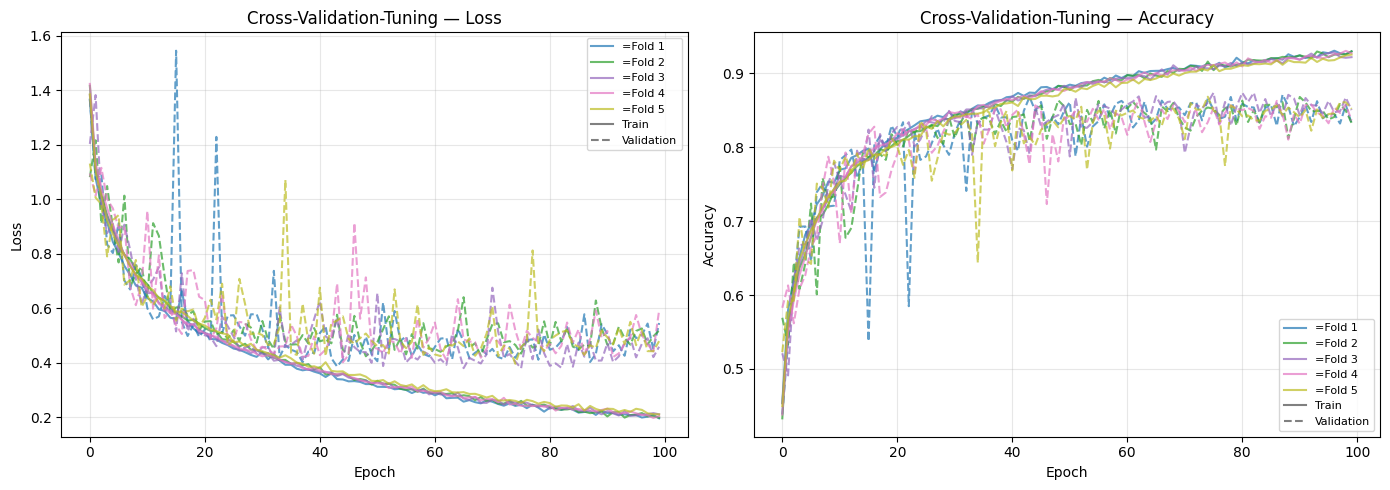

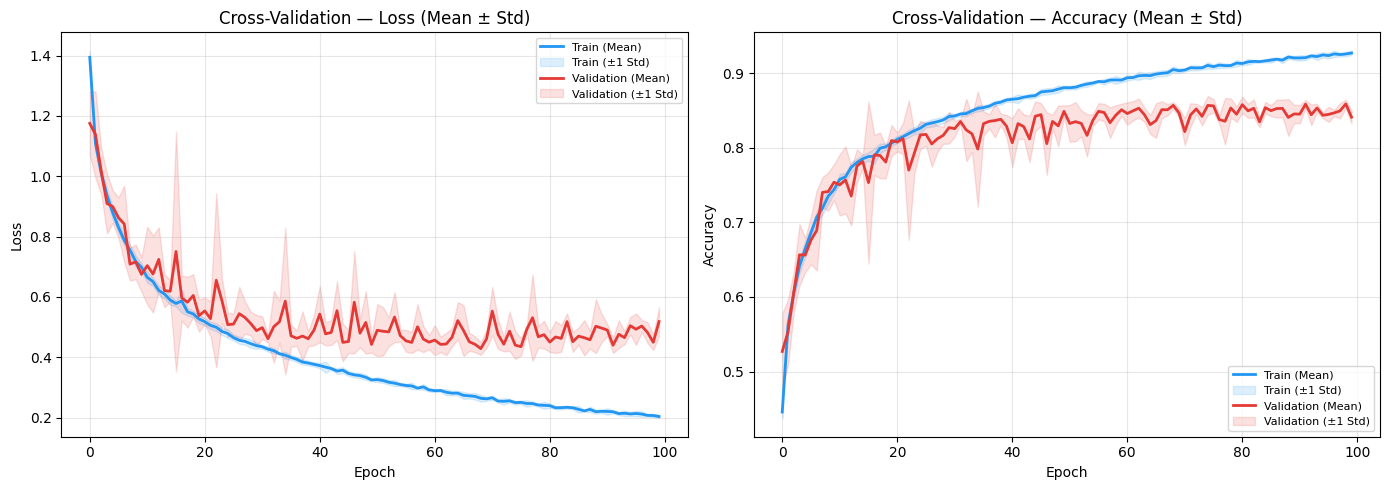

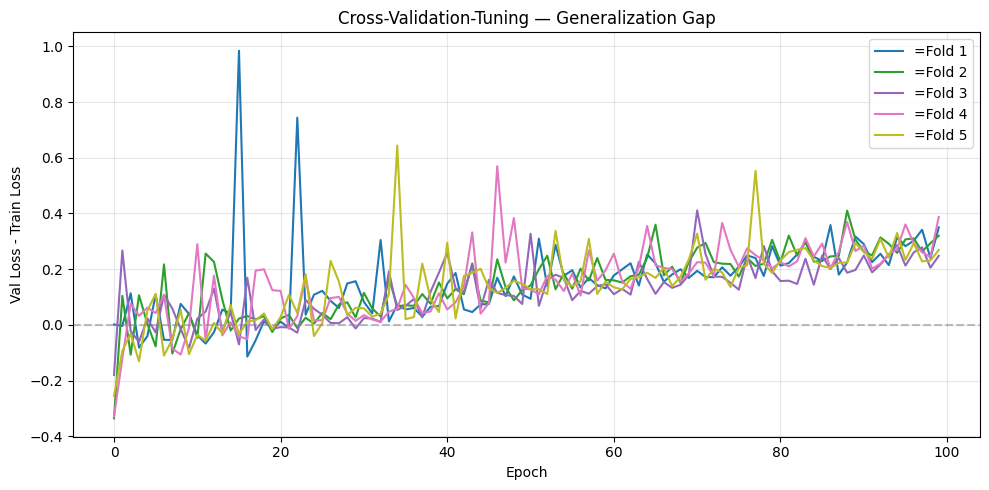

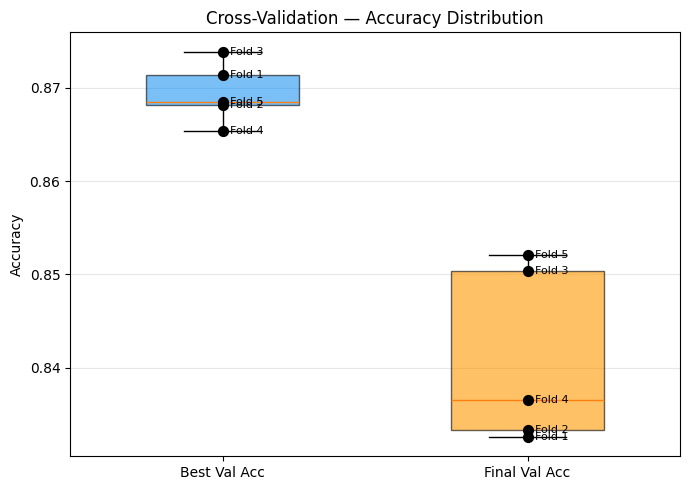

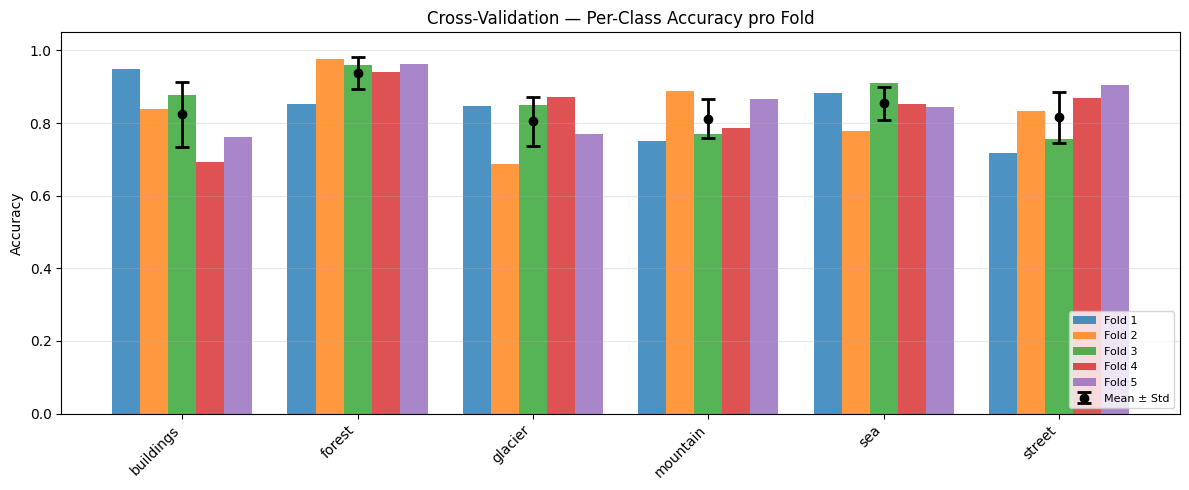

cv/mean_best_acc,▁
cv/mean_final_acc,▁
cv/std_best_acc,▁
cv/std_final_acc,▁
cv/mean_best_acc,0.86946
cv/mean_final_acc,0.84096
cv/std_best_acc,0.00293
cv/std_final_acc,0.00851


In [35]:
# Cross-Validation Ergebnisse zusammenfassen
best_accs = [r["best_val_acc"] for r in fold_results]
final_accs = [r["final_val_acc"] for r in fold_results]

print("Cross-Validation Ergebnisse:")
print(f"{'Fold':>6} | {'Best Val Acc':>12} | {'Final Val Acc':>13}")
print("-" * 40)
for r in fold_results:
    print(f"{r['fold']:>6} | {r['best_val_acc']:>12.4f} | {r['final_val_acc']:>13.4f}")
print("-" * 40)
print(f"{'Mean':>6} | {np.mean(best_accs):>12.4f} | {np.mean(final_accs):>13.4f}")
print(f"{'Std':>6} | {np.std(best_accs):>12.4f} | {np.std(final_accs):>13.4f}")

print(
    f"\nStatistischer Fehler (Best Val Acc): {np.mean(best_accs):.4f} +/- {np.std(best_accs):.4f}"
)
print(f"Hyperparameter: lr={best_lr}, batch_size={best_bs}")

# 1. Train + Val Lernkurven pro Fold (solid=Train, gestrichelt=Validation)
fold_histories = {f"Fold {r['fold']}": r["history"] for r in fold_results}
fig_folds = plot_hp_comparison(fold_histories, hp_name="", hp_label="Cross-Validation")

# 2. Mean ± Std Band
fig_band = plot_cv_mean_std_band(fold_results, title_prefix="Cross-Validation")

# 3. Generalization Gap pro Fold
fig_gap = plot_hp_gap_comparison(
    fold_histories, hp_name="", hp_label="Cross-Validation"
)

# 4. Box-Plot der CV-Ergebnisse
fig_box = plot_cv_boxplot(
    fold_results, title="Cross-Validation — Accuracy Distribution"
)

# 5. Per-Class Accuracy pro Fold
fig_per_class = plot_cv_per_class_accuracy(
    fold_predictions,
    CLASS_NAMES,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
)

# CV-Zusammenfassung an W&B loggen
run = wandb.init(
    project="del-mini-challenge",
    name="cv-summary",
    config={
        "experiment": "cross-validation-summary",
        "k_folds": K_FOLDS,
        "lr": best_lr,
        "batch_size": best_bs,
    },
    reinit=True,
)
wandb.log(
    {
        "cv/fold_learning_curves": wandb.Image(fig_folds),
        "cv/mean_std_band": wandb.Image(fig_band),
        "cv/generalization_gap": wandb.Image(fig_gap),
        "cv/boxplot": wandb.Image(fig_box),
        "cv/per_class_accuracy": wandb.Image(fig_per_class),
        "cv/mean_best_acc": np.mean(best_accs),
        "cv/std_best_acc": np.std(best_accs),
        "cv/mean_final_acc": np.mean(final_accs),
        "cv/std_final_acc": np.std(final_accs),
    }
)
for fig in [fig_folds, fig_band, fig_gap, fig_box, fig_per_class]:
    plt.close(fig)
wandb.finish()